# DoubleIntegrator — Stage 2 — Sparse Dictionary Policy Training (DPC)

Train and inspect the sparse SD-DPC policy.


## 1. Set up the system and load the stage config

Load dependencies and configuration.


In [1]:
"""Boilerplate: make the in-repo `sdpc` package importable and resolve this system."""
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_p = Path.cwd()
while not (_p / "src" / "sdpc").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import torch
from sdpc.config import load_config
from sdpc.registry import make_system

SYSTEM = "double_integrator"
device = torch.device("cpu")
system = make_system(SYSTEM, device=device)
CONFIGS = Path.cwd().parent / "configs"
RESULTS = Path.cwd().parent / "results"

print(f"System        : {SYSTEM}")
print(f"State dim nx  : {system.nx}")
print(f"Control dim nu: {system.nu}")
print(f"Sample time ts: {system.ts}")
print(f"Input bounds  : [{system.umin}, {system.umax}]")
print(f"State bounds  : [{system.xmin}, {system.xmax}]")
print(f"Discrete model: {system.is_discrete}")


System        : double_integrator
State dim nx  : 2
Control dim nu: 2
Sample time ts: 1.0
Input bounds  : [-1.0, 1.0]
State bounds  : [-5.0, 5.0]
Discrete model: True


In [2]:
cfg = load_config(CONFIGS / 'policy.yaml')

print('Resolved policy-training config:')
for k, v in cfg.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')

Resolved policy-training config:
  seed: 0
  policy_seed: 5
  init_scale: 0.01
  action_scale: 1.0
  action_gradient_mode: leaky_straight_through
  action_gradient_band: 1.0
  action_gradient_leak: 0.5
  nsteps: 100
  n_samples: 1000
  batch_size: 100
  eval_seed: 0
  eval_margin: 0.1
  init_center: [3, -3]
  init_side: 2.0
  ref_center: [-3, 3]
  ref_side: 2.0
  refstep: 1
  ellipse: {'p': 3, 'b': 1, 'c': 0.0, 'd': 0.0, 'theta': 0.0}
  lr: 0.0015
  grad_clip: 10.0
  proximal_l1: False
  epochs: 6000
  threshold: 0.002
  prune_every: 500
  prune_every_min: 500
  prune_every_decay: 50
  change_prune_every: True
  threshold_mult: 2.0
  threshold_max: 0.01
  prune_noise: 0.0
  lr_decay_enabled: True
  lr_decay_gamma: 0.95
  lr_decay_step: 100
  l1_decay: 1.0
  warmup: 100
  patience: 50
  verbosity: 1
  logger_metrics: ['train_loss', 'dev_loss', 'train_tracking_loss', 'dev_tracking_loss', 'train_l1_loss', 'dev_l1_loss', 'train_constraint_loss', 'dev_constraint_loss', 'train_total_control_

## 2. Load the identified dynamics model from Stage 1

Restore the required checkpoints.


In [3]:
from sdpc.sindy import load_model

dyn_runs = sorted((RESULTS / 'models' / 'dynamics').glob('run_*'))
assert dyn_runs, 'no SINDy dynamics runs found — run 01_system_id.ipynb first'
print('Using dynamics checkpoint:', dyn_runs[-1])

sindy = load_model(dyn_runs[-1] / 'saved_models' / 'sindy.pt', device=device)
print('\nLoaded dynamics model:')
sindy.pretty_print()

Using dynamics checkpoint: /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/DoubleIntegrator/results/models/dynamics/run_4

Loaded dynamics model:
dx0/dt = +1.0000e+00·x0 + +1.0000e+00·u0
dx1/dt = +1.0000e+00·x1 + +1.0000e+00·u1


## 3. Build the sparse policy library and model

Define the system and problem.


In [4]:
from sdpc.sindy import CompiledFunctionLibrary, SINDyVectorized

policy_lib_cfg = system.policy_library_cfg()
print('Policy library config:', policy_lib_cfg)

plib = CompiledFunctionLibrary(**policy_lib_cfg)
policy = SINDyVectorized(
    library=plib, n_out=system.nu,
    policy_name=[f'u{i}' for i in range(system.nu)],
    device=device, seed=cfg.get('policy_seed', 0),
)
init_scale = cfg.get('init_scale')
if init_scale is not None:
    for i in range(system.nu):
        policy.Xi[i].data.mul_(init_scale)

print(f'\nPolicy library has {plib.shape[0]} candidate terms:')
print(plib.function_names)
print('\nInitial (untrained) policy:')
policy.pretty_print()

Policy library config: {'n_features': 2, 'n_control': 2, 'is_policy': True, 'include_bias': True, 'max_degree': 2, 'add_sqrt': False, 'add_xu': True, 'add_u_prod': True, 'add_fourier': True, 'max_freq': 2}

Policy library has 29 candidate terms:
['1', 'x0', 'x1', 'r0', 'r1', 'x0^2', 'x0*x1', 'x1^2', 'r0*r1', 'x0*r0', 'x0*r1', 'x1*r0', 'x1*r1', 'sin(1·x0)', 'sin(2·x0)', 'sin(1·x1)', 'sin(2·x1)', 'cos(1·x0)', 'cos(2·x0)', 'cos(1·x1)', 'cos(2·x1)', 'sin(1·r0)', 'sin(2·r0)', 'sin(1·r1)', 'sin(2·r1)', 'cos(1·r0)', 'cos(2·r0)', 'cos(1·r1)', 'cos(2·r1)']

Initial (untrained) policy:
u0 = +3.3025e-04·1 + -3.7389e-04·x0 + +4.0747e-04·x1 + +3.1993e-04·r0 + +4.2010e-04·r1 + -3.8335e-04·x0^2 + -3.3561e-04·x0*x1 + +2.3792e-04·x1^2 + -4.6674e-04·r0*r1 + +4.9418e-04·x0*r0 + +1.0643e-04·x0*r1 + +6.4571e-05·x1*r0 + -4.2759e-04·x1*r1 + +1.5934e-04·sin(1·x0) + +2.1501e-04·sin(2·x0) + +7.9328e-05·sin(1·x1) + +4.8093e-04·sin(2·x1) + +1.5016e-04·cos(1·x0) + -4.4337e-04·cos(2·x0) + +4.2011e-04·cos(1·x1) + +1

## 4. Generate policy-training data

Prepare the required training data.


In [5]:
train_loader, dev_loader = system.make_policy_data(cfg, device)

batch = next(iter(train_loader))
print('Train batch keys:', list(batch.keys()))
print('xn shape (batch, 1, nx):', tuple(batch['xn'].shape))
print('r  shape (batch, horizon+1, nref):', tuple(batch['r'].shape))

Train batch keys: ['xn', 'r', 'obs_p', 'obs_b', 'obs_c', 'obs_d', 'name']
xn shape (batch, 1, nx): (100, 1, 2)
r  shape (batch, horizon+1, nref): (100, 101, 2)


## 5. Train the sparse policy (differentiable predictive control)

Optimize the controller parameters.


In [6]:
from sdpc.training import train_policy
from sdpc.io import CustomLogger

logger = CustomLogger(args=None, savedir=str(RESULTS / 'logs' / 'policy_nb'),
                      verbosity=cfg['verbosity'],
                      stdout=cfg.get('logger_metrics', ['train_loss', 'dev_loss']))
train_policy(system, sindy, policy, train_loader, dev_loader, cfg, device,
             logger=logger, action_scale=cfg.get('action_scale', 1.0))

None
epoch: 0	train_loss: 3.734e+02	train_tracking_loss: 3.039e+02	train_l1_loss: 1.051e-04	train_constraint_loss: 6.875e+01	train_total_control_action_l1: 9.469e+00	learning_rate: 1.500e-03	dev_loss: 2.694e+02	dev_tracking_loss: 2.026e+02	dev_l1_loss: 1.612e-04	dev_constraint_loss: 6.579e+01	dev_total_control_action_l1: 9.177e+00	eltime:  1.16003
epoch: 1	train_loss: 2.129e+02	train_tracking_loss: 1.641e+02	train_l1_loss: 1.865e-04	train_constraint_loss: 4.761e+01	train_total_control_action_l1: 9.272e+00	learning_rate: 1.500e-03	dev_loss: 1.445e+02	dev_tracking_loss: 1.097e+02	dev_l1_loss: 2.127e-04	dev_constraint_loss: 3.344e+01	dev_total_control_action_l1: 1.019e+01	eltime:  2.21432
epoch: 2	train_loss: 1.143e+02	train_tracking_loss: 8.606e+01	train_l1_loss: 2.261e-04	train_constraint_loss: 2.675e+01	train_total_control_action_l1: 1.028e+01	learning_rate: 1.500e-03	dev_loss: 8.183e+01	dev_tracking_loss: 5.586e+01	dev_l1_loss: 2.396e-04	dev_constraint_loss: 2.441e+01	dev_total_contro

{}

## 6. Inspect the learned policy

Inspect policy performance.


In [7]:
print('Learned sparse policy:')
policy.pretty_print()
print()
print('Active terms per output:', [len(idx) for idx in policy.active_idx])
print('Total active terms      :', sum(len(idx) for idx in policy.active_idx))

Learned sparse policy:
u0 = -3.4409e-02·x0 + +1.1809e-02·x1 + +3.3027e-02·r0 + -2.9861e-02·r1 + -6.1995e-03·r0*r1 + -2.1325e-02·sin(1·r0)
u1 = -2.3651e-02·x1 + -9.5745e-03·x0*r1 + +1.2364e-02·sin(1·x1) + -2.6566e-02·sin(1·r0)

Active terms per output: [6, 4]
Total active terms      : 10


## 7. Visualize the active coefficients

Inspect the surviving coefficients.


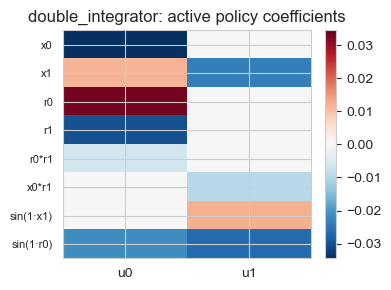

In [8]:
from sdpc.plotting import plot_coef_heatmap
import matplotlib.pyplot as plt

plot_coef_heatmap(policy, title=f'{SYSTEM}: active policy coefficients')
plt.show()

## 8. Sanity-check a nominal closed-loop rollout

Visualize the closed-loop response.


In [19]:
from sdpc.eval import make_test_data, rollout_closed_loop

nominal_plant = system.discrete_step(sindy)
eval_seed = cfg.get('eval_seed', 9)
eval_margin = cfg.get('eval_margin', 0.6)
generator = torch.Generator(device='cpu').manual_seed(eval_seed)
sample_scale = 1.0 - 2.0 * eval_margin
init_center = torch.tensor(cfg['init_center'], dtype=torch.float32)
ref_center = torch.tensor(cfg['ref_center'], dtype=torch.float32)
x0 = (init_center + cfg['init_side'] * sample_scale * (torch.rand(system.nx, generator=generator) - 0.5)).tolist()
ref = [-2.2,3.3]
data = make_test_data(system.nx, cfg["nsteps"], x0, ref, device=device)

res = rollout_closed_loop(policy, nominal_plant, data,
                          umin=system.umin, umax=system.umax,
                          action_scale=cfg.get('action_scale', 1.0))
print('evaluation seed:', eval_seed)
print('x0:', data['xn'][0, 0].tolist())
print('reference:', data['r'][0, 0].tolist())
print('final state:', res['x_traj'][0, -1].tolist())

evaluation seed: 0
x0: [2.9940104484558105, -2.570845127105713]
reference: [-2.200000047683716, 3.299999952316284]
final state: [-2.2893528938293457, 3.236078977584839]


### Obstacle-avoidance trajectory

Visualize the closed-loop response.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


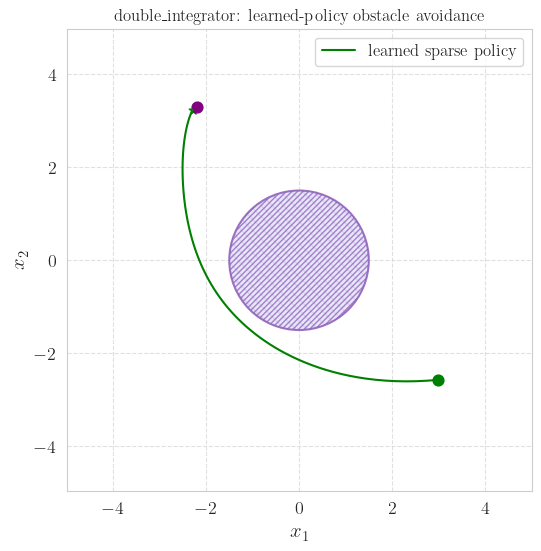

In [20]:
from sdpc.plotting import plot_trajectories_with_ellipse

e = cfg['ellipse']
plot_trajectories_with_ellipse(
    [
        {
            'traj': res['x_traj'],
            'label': 'learned sparse policy',
            'color': 'green',
        }
    ],
    r=data['r'],
    p=e['p'], b=e['b'], c=e['c'], d=e['d'], theta=e.get('theta', 0.0),
    xmin=system.xmin, xmax=system.xmax,
    title=f'{SYSTEM}: learned-policy obstacle avoidance',
)
plt.show()

## 9. Save the policy (optional)

Prefer `scripts/DoubleIntegrator/train_sd_dpc.py` for a tracked run; to save directly from this notebook, uncomment below.

In [21]:
from sdpc.io import new_policy_run_dir, snapshot_config
from sdpc.sindy import save_model
run_dir = new_policy_run_dir(RESULTS, 'sparse')
save_model(policy, run_dir / 'saved_models' / 'policy_sparse.pt')
snapshot_config(run_dir, cfg)
print('Saved to', run_dir)

Saved to /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/DoubleIntegrator/results/models/policies/sd_dpc/run_1
